In [ ]:
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# 1. Daten laden (Die neuen finalen Splits)
train_df = pd.read_csv("sample_datatrain_final.csv", index_col=0, parse_dates=True)
val_df = pd.read_csv("sample_dataval_final.csv", index_col=0, parse_dates=True)
test_df = pd.read_csv("sample_datatest_final.csv", index_col=0, parse_dates=True)

target = "target_load_24h"
features = [c for c in train_df.columns if c != target]

scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[features])
X_val   = scaler.transform(val_df[features])
X_test  = scaler.transform(test_df[features])

y_train = train_df[target].values
y_val   = val_df[target].values
y_test  = test_df[target].values

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_mae = mean_absolute_error(y_val, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results.append({
        "Model": name,
        "VAL_MAE": val_mae,
        "VAL_RMSE": val_rmse,
        "TEST_MAE": test_mae,
        "TEST_RMSE": test_rmse
    })

    print(f"{name}")
    print(f"VAL  MAE: {val_mae:.3f} | RMSE: {val_rmse:.3f}")
    print(f"TEST MAE: {test_mae:.3f} | RMSE: {test_rmse:.3f}")
    print("-"*40)

results_df = pd.DataFrame(results)
results_df.sort_values(by="TEST_RMSE")



Linear Regression
VAL  MAE: 554.714 | RMSE: 731.485
TEST MAE: 528.967 | RMSE: 695.860
----------------------------------------
Ridge Regression
VAL  MAE: 554.723 | RMSE: 731.491
TEST MAE: 528.977 | RMSE: 695.871
----------------------------------------
Random Forest
VAL  MAE: 320.435 | RMSE: 472.764
TEST MAE: 344.017 | RMSE: 504.576
----------------------------------------
Gradient Boosting
VAL  MAE: 410.194 | RMSE: 546.006
TEST MAE: 412.958 | RMSE: 564.745
----------------------------------------
XGBoost
VAL  MAE: 334.279 | RMSE: 475.276
TEST MAE: 351.233 | RMSE: 497.657
----------------------------------------


,Model,VAL_MAE,VAL_RMSE,TEST_MAE,TEST_RMSE
4,XGBoost,334.278662,475.275925,351.232813,497.656519
2,Random Forest,320.435172,472.764105,344.017210,504.576165
3,Gradient Boosting,410.194062,546.006276,412.958493,564.744889
0,Linear Regression,554.714284,731.485263,528.967140,695.859570
1,Ridge Regression,554.723163,731.491304,528.977377,695.871035


Bar Plot — Test MAE Comparison

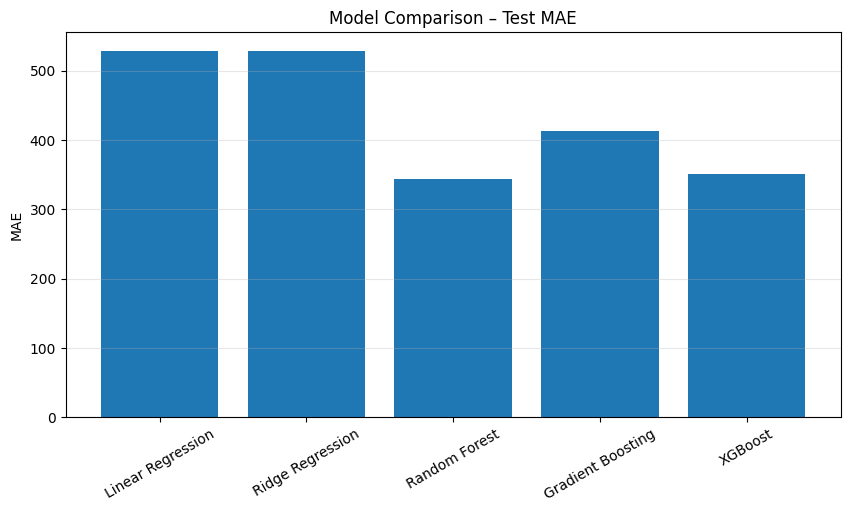

In [2]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["TEST_MAE"])

plt.title("Model Comparison – Test MAE")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

Bar Plot — Test RMSE Comparison

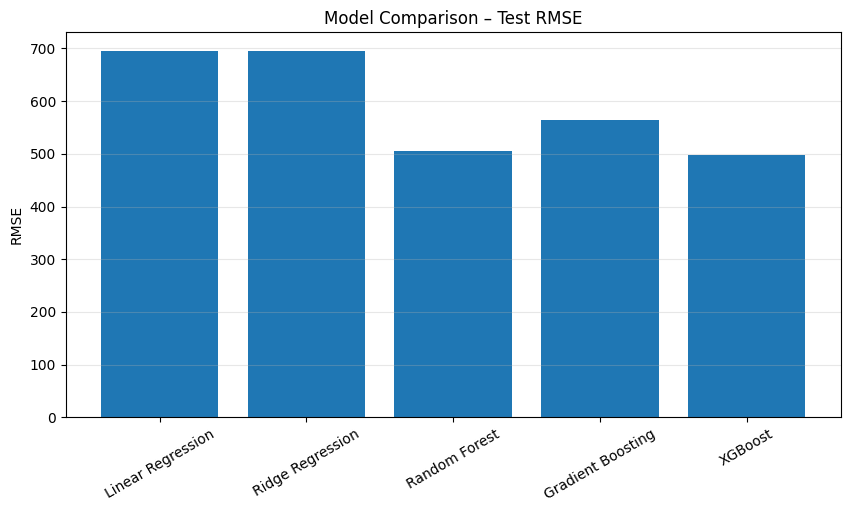

In [3]:
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["TEST_RMSE"])

plt.title("Model Comparison – Test RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.show()

Train vs Test Gap (Overfitting Check)

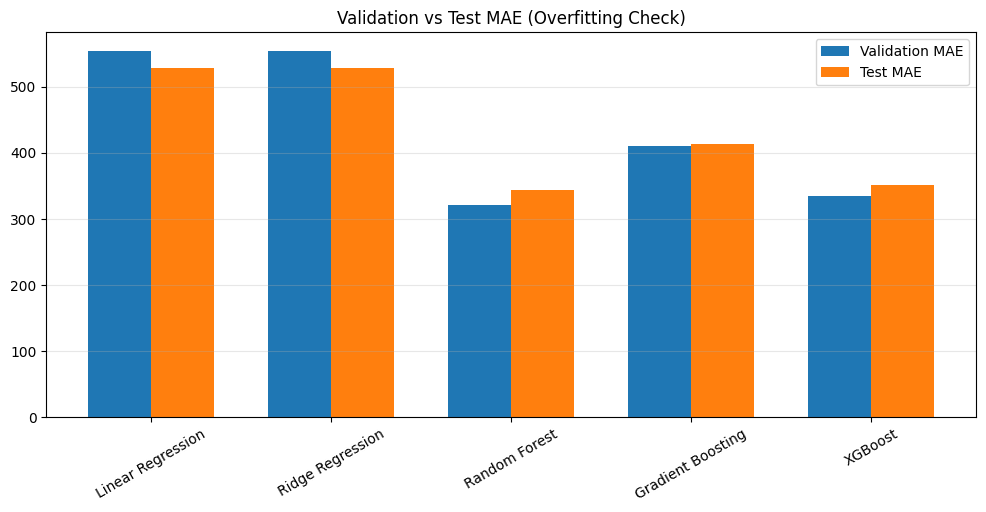

In [4]:
x = np.arange(len(results_df["Model"]))
width = 0.35

plt.figure(figsize=(12,5))

plt.bar(x - width/2, results_df["VAL_MAE"], width, label="Validation MAE")
plt.bar(x + width/2, results_df["TEST_MAE"], width, label="Test MAE")

plt.xticks(x, results_df["Model"], rotation=30)
plt.title("Validation vs Test MAE (Overfitting Check)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

Combined MAE + RMSE View

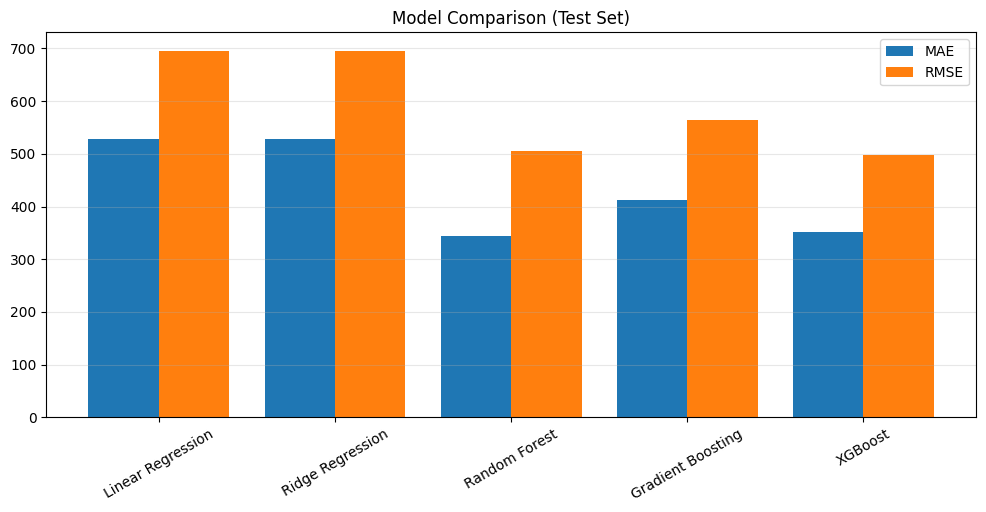

In [5]:
plt.figure(figsize=(12,5))

x = np.arange(len(results_df["Model"]))

plt.bar(x - 0.2, results_df["TEST_MAE"], width=0.4, label="MAE")
plt.bar(x + 0.2, results_df["TEST_RMSE"], width=0.4, label="RMSE")

plt.xticks(x, results_df["Model"], rotation=30)
plt.title("Model Comparison (Test Set)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()